<a href="https://colab.research.google.com/github/lkostenko/KMA/blob/main/test_task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

In [26]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "#F8F9FA",
    "grid.color": "#E0E0E0",
    "grid.linewidth": 0.8,
})

COLORS = {"ms_1": "#378ADD", "ms_2": "#1D9E75", "ms_3": "#D85A30"}
FILE_PATH = "/content/Data Analyst Test Task Data new – Kostenko.xlsx"

In [27]:
df = pd.read_excel(FILE_PATH, sheet_name="Task 3")

In [28]:
df["install_date"] = pd.to_datetime(df["install_date"])

In [29]:
agg = df.groupby(["media_source", "country_code"]).agg(
    spend=("spend_usd", "sum"),
    revenue=("erevenue_12month_usd", "sum"),
    subscribers=("subscribers", "sum"),
).reset_index()

In [30]:
agg["roas"] = agg["revenue"] / agg["spend"].replace(0, np.nan)
agg["roi"]  = (agg["revenue"] - agg["spend"]) / agg["spend"].replace(0, np.nan) * 100
agg["cps"]  = agg["spend"] / agg["subscribers"].replace(0, np.nan)
agg["profit"] = agg["revenue"] - agg["spend"]

In [31]:
src = agg.groupby("media_source").agg(
    spend=("spend", "sum"),
    revenue=("revenue", "sum"),
    subscribers=("subscribers", "sum"),
    profit=("profit", "sum"),
).reset_index()

In [32]:
src["roas"] = src["revenue"] / src["spend"]
src["roi"]  = (src["revenue"] - src["spend"]) / src["spend"] * 100
src["cps"]  = src["spend"] / src["subscribers"]

In [33]:
daily = df.groupby(["media_source", "install_date"]).agg(
    spend=("spend_usd", "sum"),
    revenue=("erevenue_12month_usd", "sum"),
    subscribers=("subscribers", "sum"),
).reset_index()
daily["roas"] = daily["revenue"] / daily["spend"].replace(0, np.nan)

In [34]:
def top_geo(ms, n=8):
    s = agg[(agg["media_source"] == ms) & (agg["spend"] > 50) & (agg["subscribers"] > 0)]
    return s.sort_values("roas", ascending=False).head(n)

In [35]:
def stop_geo(ms, n=8):
    s = agg[(agg["media_source"] == ms) & (agg["spend"] > 50)]
    return s[s["roas"] < 1.0].sort_values("roas").head(n)

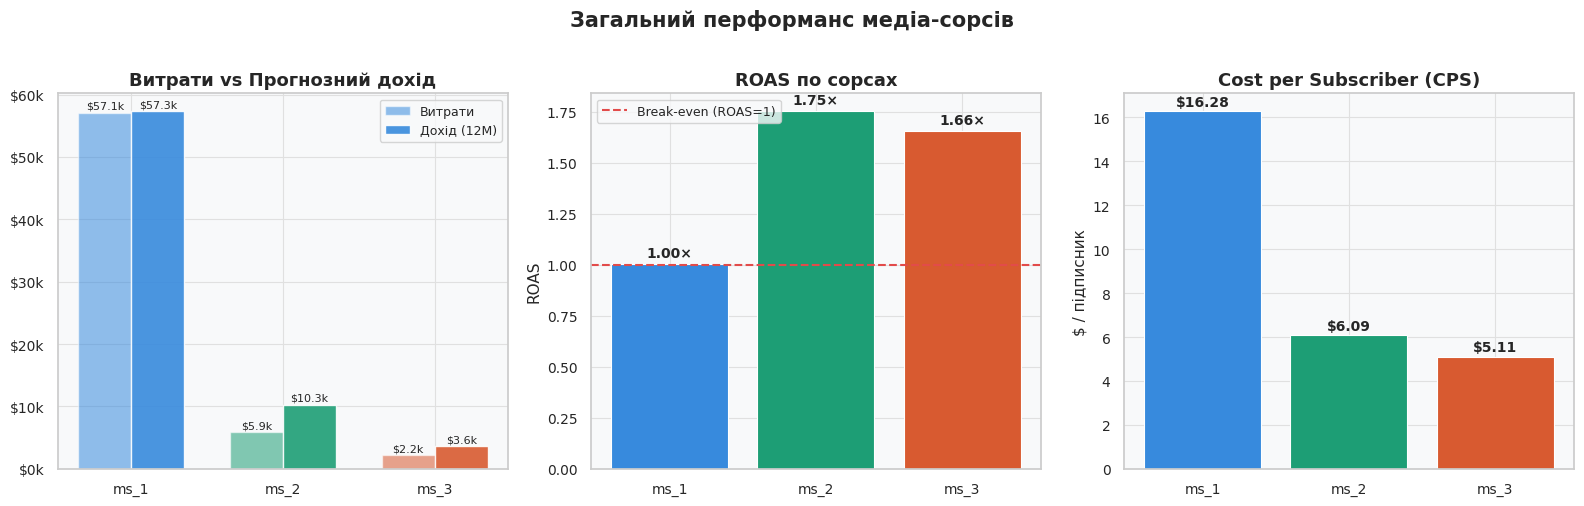

In [36]:
fig1, axes = plt.subplots(1, 3, figsize=(16, 5))
fig1.suptitle("Загальний перформанс медіа-сорсів", fontsize=15, fontweight="bold", y=1.01)

sources = src["media_source"].tolist()
bar_colors = [COLORS[s] for s in sources]

# Витрати vs Дохід
ax = axes[0]
x = np.arange(len(sources))
w = 0.35
b1 = ax.bar(x - w/2, src["spend"],   width=w, color=bar_colors, alpha=0.55, label="Витрати")
b2 = ax.bar(x + w/2, src["revenue"], width=w, color=bar_colors, alpha=0.9,  label="Дохід (12M)")
ax.set_title("Витрати vs Прогнозний дохід")
ax.set_xticks(x); ax.set_xticklabels(sources)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1000:.0f}k"))
ax.legend(fontsize=9)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 300,
            f"${h/1000:.1f}k", ha="center", va="bottom", fontsize=8)
# ROAS
ax = axes[1]
bars = ax.bar(sources, src["roas"], color=bar_colors, edgecolor="white", linewidth=0.8)
ax.axhline(1.0, color="#E24B4A", ls="--", lw=1.5, label="Break-even (ROAS=1)")
ax.set_title("ROAS по сорсах")
ax.set_ylabel("ROAS")
ax.legend(fontsize=9)
for bar, val in zip(bars, src["roas"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.2f}×", ha="center", va="bottom", fontsize=10, fontweight="bold")

# CPS
ax = axes[2]
bars = ax.bar(sources, src["cps"], color=bar_colors, edgecolor="white", linewidth=0.8)
ax.set_title("Cost per Subscriber (CPS)")
ax.set_ylabel("$ / підписник")
for bar, val in zip(bars, src["cps"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"${val:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout();


**Витрати vs Дохід**

 ms_1 поглинає 87% всього бюджету ($57k із $65k сукупних витрат), однак генерує лише мінімальний прибуток — $259. ms_2 при витратах $5.9k приносить $4 409 прибутку, ms_3 при $2.2k - $1 428


** ROAS**

  ms_2 (1.75×) та ms_3 (1.66×) перевищують break-even більш ніж у 1.5 рази, тоді як ms_1 ледь тримається на рівні 1.00×. Кожен вкладений долар у ms_2 повертає $1.75 доходу - у 1.7 рази ефективніше, ніж ms_1

 **CPS**

  ms_3 має найнижчу вартість підписника - $5.11, ms_2 - $6.09, тоді як ms_1 коштує $16.28 за підписника. ms_1 залучає підписників утричі дорожче при значно нижчій ефективності.

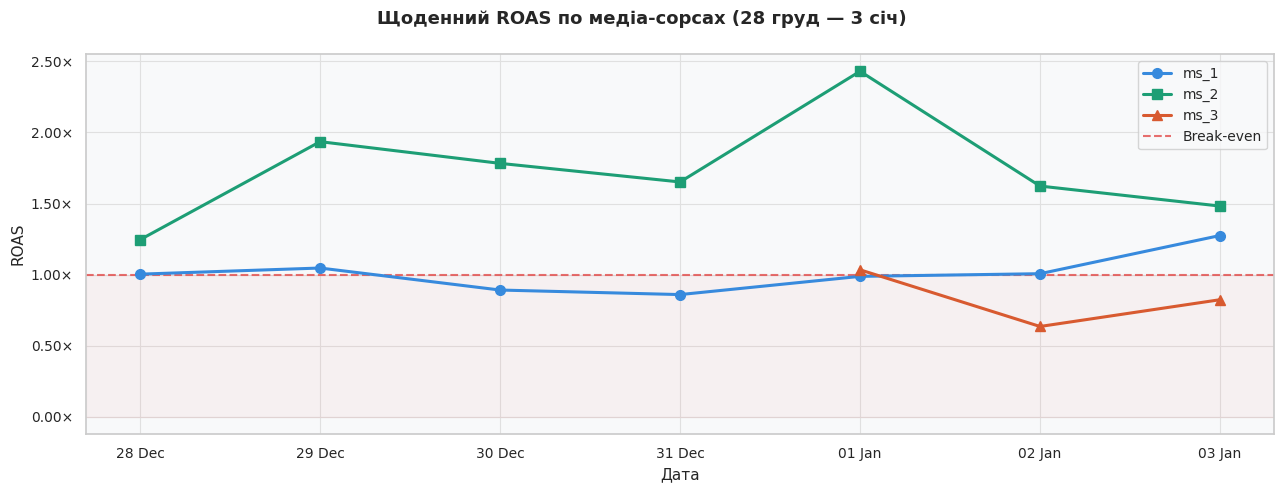

In [37]:
fig2, ax = plt.subplots(figsize=(13, 5))
fig2.suptitle("Щоденний ROAS по медіа-сорсах (28 груд — 3 січ)", fontsize=13, fontweight="bold")

markers = {"ms_1": "o", "ms_2": "s", "ms_3": "^"}
for ms, grp in daily.groupby("media_source"):
    g = grp.sort_values("install_date")
    mask = g["roas"].notna()
    ax.plot(g.loc[mask, "install_date"], g.loc[mask, "roas"],
            color=COLORS[ms], marker=markers[ms], linewidth=2.2,
            markersize=7, label=ms, zorder=3)

ax.axhline(1.0, color="#E24B4A", ls="--", lw=1.5, alpha=0.8, label="Break-even")
ax.axhspan(0, 1.0, alpha=0.05, color="#E24B4A")
ax.set_ylabel("ROAS")
ax.set_xlabel("Дата")
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%d %b"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2f}×"))
plt.tight_layout();

ms_2 впродовж усього тижня стабільно тримається вище 1.5×, із піком 2.43× на 1 січня. Жодного дня не опускався нижче break-even — найнадійніший сорс


ms_1 двічі провалювався нижче 1.0 — 30 грудня (0.89×) та 31 грудня (0.86×), що означало збиткові дні при витратах $11.2k і $8.9k відповідно. Відновлення відбулося лише 3 січня (1.28×)


ms_3 розпочав платну закупівлю лише з 1 січня.
 З трьох оплачених днів лише 1 січня був прибутковим (1.03×), решта — збиткові: 2 січня 0.64×, 3 січня 0.82×. Вкрай нестабільна динаміка для нового сорсу.

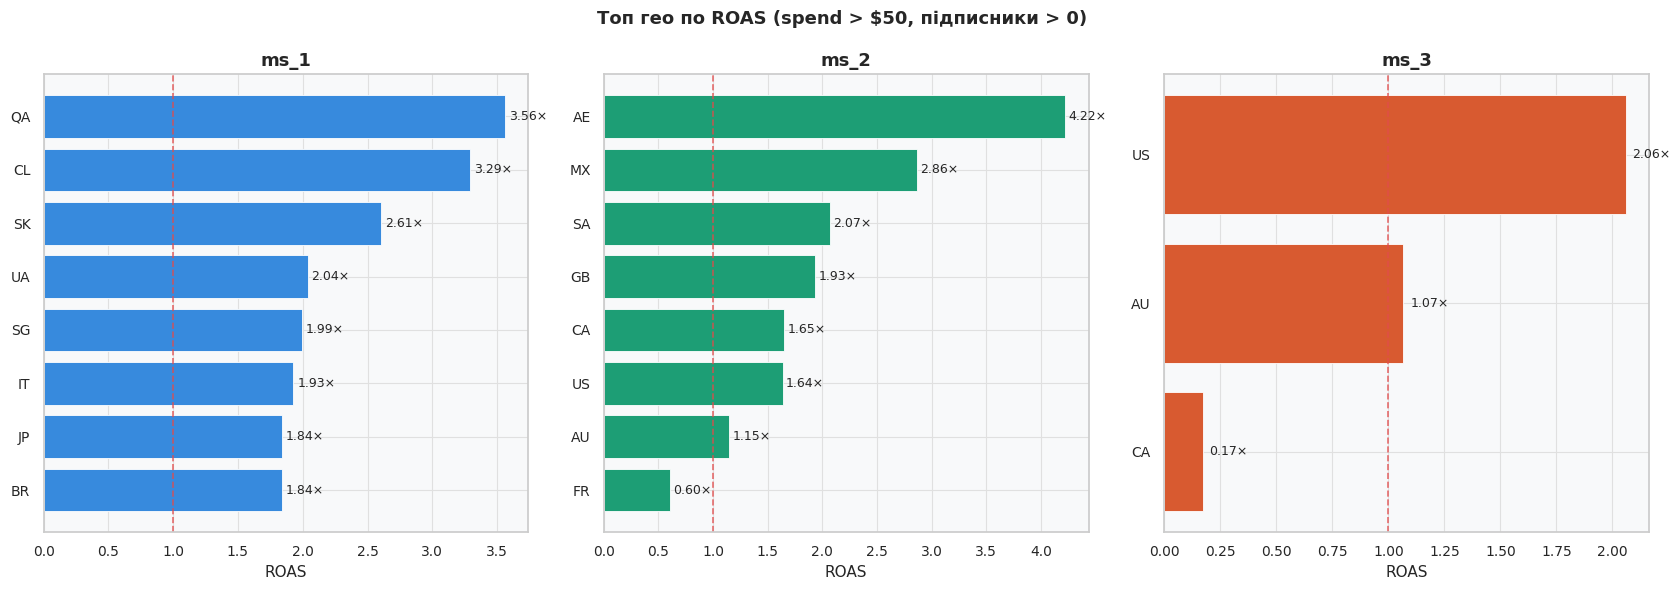

In [38]:
fig3, axes = plt.subplots(1, 3, figsize=(17, 6))
fig3.suptitle("Топ гео по ROAS (spend > $50, підписники > 0)", fontsize=13, fontweight="bold")

for ax, ms in zip(axes, ["ms_1", "ms_2", "ms_3"]):
    tg = top_geo(ms)
    if tg.empty:
        ax.axis("off"); continue
    tg = tg.sort_values("roas")
    bars = ax.barh(tg["country_code"], tg["roas"],
                   color=COLORS[ms], edgecolor="white", linewidth=0.6)
    ax.axvline(1.0, color="#E24B4A", ls="--", lw=1.2, alpha=0.8)
    ax.set_title(ms)
    ax.set_xlabel("ROAS")
    for bar, val in zip(bars, tg["roas"]):
        ax.text(val + 0.03, bar.get_y() + bar.get_height()/2,
                f"{val:.2f}×", va="center", fontsize=9)

plt.tight_layout();


ms_1 демонструє найвищий ROAS у менших ринках: QA (3.56×, ROI +256%), CL (3.29×, +229%), SK (2.61×, +161%). Серед великих ринків вирізняються UA (2.04×) та IT (1.93×, 1 632 витрат - 3 147 доходу) і BR (1.84×, 1 228- 2 256). Ці гео явно недофінансовані відносно їхнього потенціалу


ms_2 очолює AE з ROAS 4.22× (+322% ROI) при мінімальних витратах 70 - очевидний кандидат для агресивного масштабування. GB (1.93×) та US (1.64×) генерують найбільший абсолютний прибуток — 1 816 та 1 779 відповідно.


ms_3 показує позитивний результат лише в US (2.06×, ROI +106%) та AU (1.07×, ROI +7%). Вибірка мала - потрібне розширення географії для коректної оцінки сорсу.

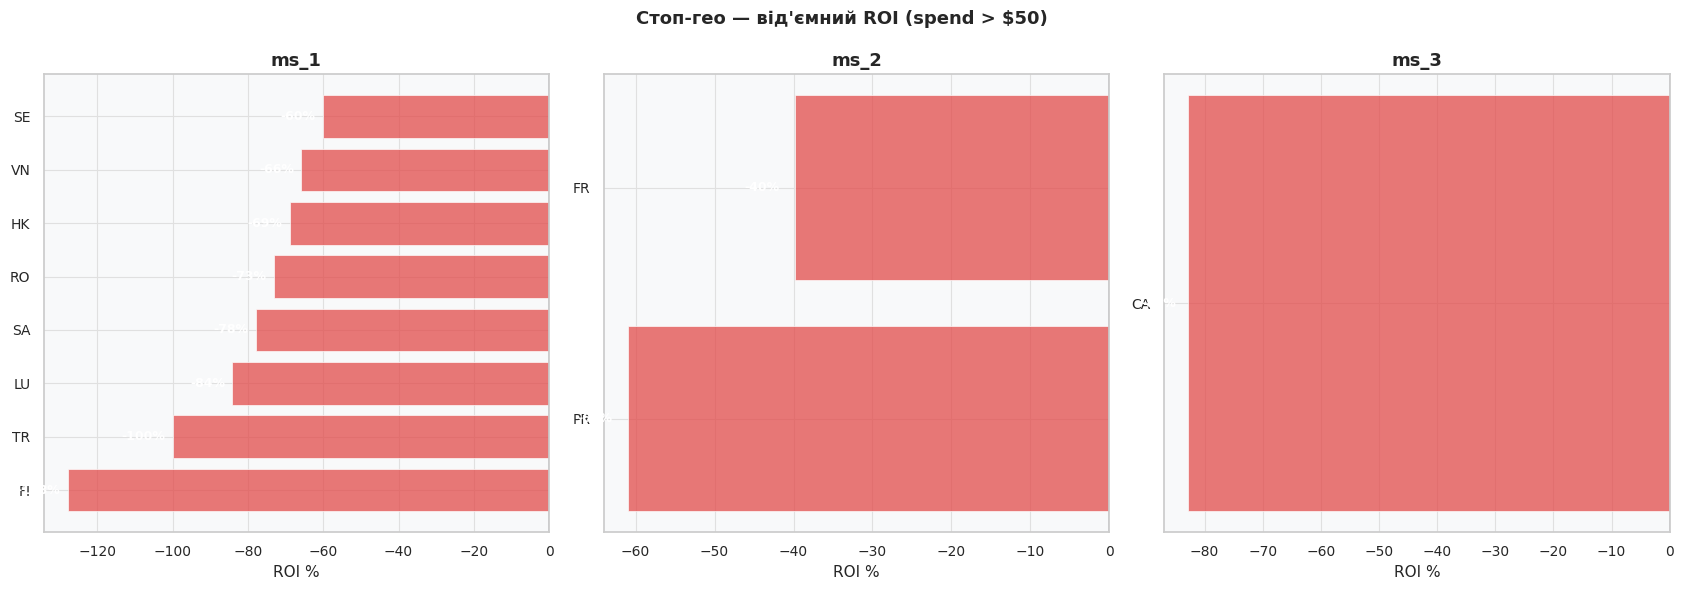

In [39]:
fig4, axes = plt.subplots(1, 3, figsize=(17, 6))
fig4.suptitle("Стоп-гео — від'ємний ROI (spend > $50)", fontsize=13, fontweight="bold")

for ax, ms in zip(axes, ["ms_1", "ms_2", "ms_3"]):
    sg = stop_geo(ms)
    if sg.empty:
        ax.set_title(ms)
        ax.text(0.5, 0.5, "Немає збиткових\nгео (spend > $50)",
                ha="center", va="center", transform=ax.transAxes, fontsize=11, color="gray")
        ax.axis("off"); continue
    sg = sg.sort_values("roi")
    bars = ax.barh(sg["country_code"], sg["roi"],
                   color="#E24B4A", alpha=0.75, edgecolor="white", linewidth=0.6)
    ax.axvline(0, color="#444", lw=1.0, ls="-")
    ax.set_title(ms)
    ax.set_xlabel("ROI %")
    for bar, val in zip(bars, sg["roi"]):
        ax.text(val - 2, bar.get_y() + bar.get_height()/2,
                f"{val:.0f}%", va="center", ha="right", fontsize=9, color="white", fontweight="bold")

plt.tight_layout();

ms_1 має 8 гео з критично негативним ROI при витратах понад 50. Найгірші результати показують FI (ROI −128%, дохід від’ємний −24), TR (ROI −100%, витрати 104 при нульовому доході) та LU (ROI −84%). Серед гео з найбільшими витратами збитковими також є SE (ROI −60%, витрати 615), IN (ROI −33%, витрати 1168) та RU (ROI −42%, витрати 638). Сукупні втрати по цих гео становлять близько 5400.

ms_2 має лише 2 збиткові гео: PR (ROI −61%, витрати 72) та FR (ROI −40%, витрати 252). Загальний обсяг втрат становить близько 176 і є незначним, однак FR потребує окремого контролю через відносно високий бюджет.

ms_3 має лише одне збиткове гео CA: витрати 407 при доході 70, ROI −83%. Це приблизно 19% бюджету сорсу, який не приносить конверсії в дохід.

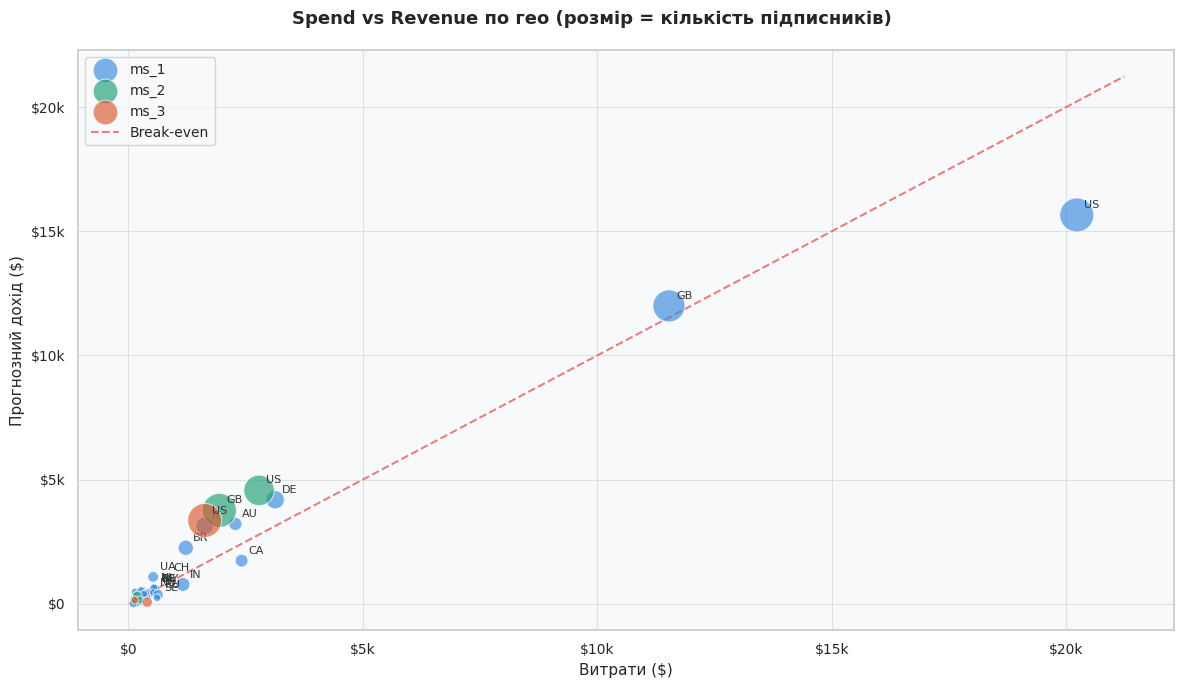

In [40]:
fig5, ax = plt.subplots(figsize=(12, 7))
fig5.suptitle("Spend vs Revenue по гео (розмір = кількість підписників)", fontsize=13, fontweight="bold")

for ms in ["ms_1", "ms_2", "ms_3"]:
    sub = agg[(agg["media_source"] == ms) & (agg["spend"] > 100)].copy()
    sizes = (sub["subscribers"] / sub["subscribers"].max() * 600).clip(lower=30)
    sc = ax.scatter(sub["spend"], sub["revenue"],
                    s=sizes, c=COLORS[ms], alpha=0.65, edgecolors="white",
                    linewidth=0.8, label=ms, zorder=3)
    for _, row in sub[sub["spend"] > 500].iterrows():
        ax.annotate(row["country_code"],
                    (row["spend"], row["revenue"]),
                    textcoords="offset points", xytext=(5, 5),
                    fontsize=8, color="#333")

# Діагональ break-even
lim = max(agg["spend"].max(), agg["revenue"].max()) * 1.05
ax.plot([0, lim], [0, lim], color="#E24B4A", ls="--", lw=1.5, alpha=0.7, label="Break-even")
ax.set_xlabel("Витрати ($)")
ax.set_ylabel("Прогнозний дохід ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1000:.0f}k" if v >= 1000 else f"${v:.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1000:.0f}k" if v >= 1000 else f"${v:.0f}"))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

Більшість бульбашок ms_2 та ms_3 розташовані вище діагоналі break-even — сорси генерують дохід вище витрат. Бульбашки ms_1 переважно знаходяться біля діагоналі або нижче неї.

Найбільш помітний аномальний кейс — ms_1 US: найбільша бульбашка (800 підписників, витрати 20224), але знаходиться нижче діагоналі (ROAS 0.77×, збиток). Аналогічно ms_1 CA: витрати 2418 при доході 1739 (ROAS 0.72×). Обидва гео є найбільшими за витратами, але збитковими — саме вони формують основний негативний вплив на ms_1.

Натомість ms_2 GB (витрати 1945, дохід 3762) та ms_3 US (витрати 1631, дохід 3358) розташовані значно вище діагоналі break-even, що візуально підтверджує їх високу ефективність

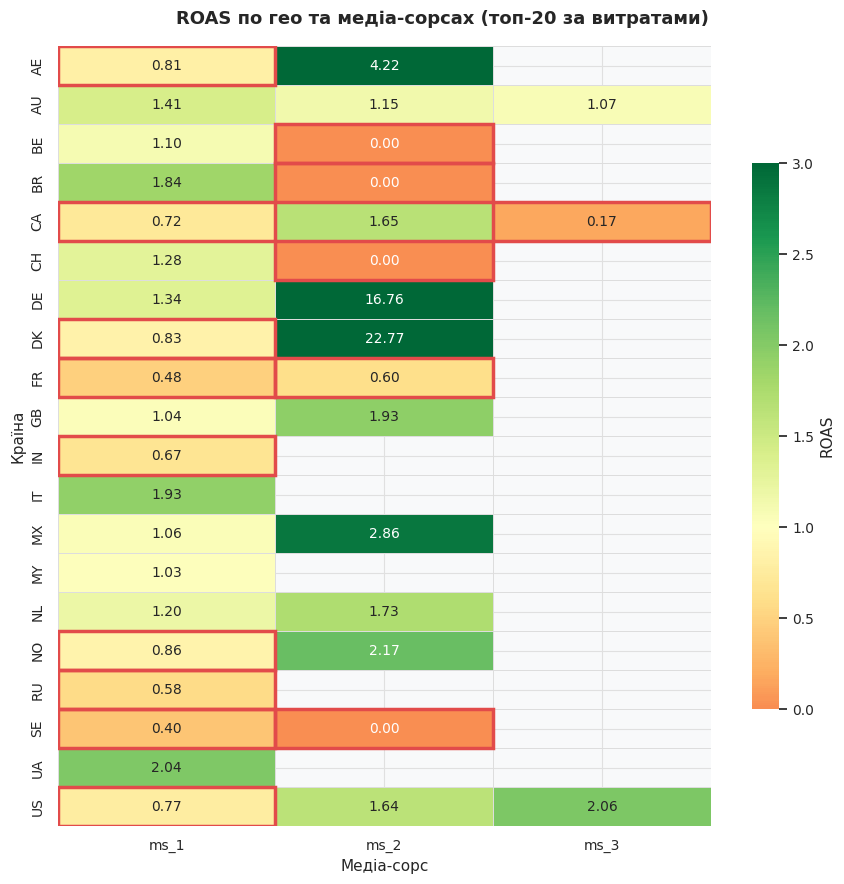

In [41]:
top_countries = (
    agg[agg["spend"] > 50]
    .groupby("country_code")["spend"].sum()
    .sort_values(ascending=False)
    .head(20).index.tolist()
)
heat_data = agg[agg["country_code"].isin(top_countries)].pivot_table(
    index="country_code", columns="media_source", values="roas"
)

fig6, ax = plt.subplots(figsize=(9, 9))
fig6.suptitle("ROAS по гео та медіа-сорсах (топ-20 за витратами)", fontsize=13, fontweight="bold")

mask = heat_data.isna()
sns.heatmap(
    heat_data, annot=True, fmt=".2f", cmap="RdYlGn",
    center=1.0, vmin=0, vmax=3,
    linewidths=0.5, linecolor="#ddd",
    mask=mask, ax=ax,
    cbar_kws={"label": "ROAS", "shrink": 0.7},
    annot_kws={"size": 10},
)
ax.set_xlabel("Медіа-сорс", fontsize=11)
ax.set_ylabel("Країна", fontsize=11)

# Виділити клітинки з ROAS < 1 рамкою
for i, country in enumerate(heat_data.index):
    for j, ms in enumerate(heat_data.columns):
        val = heat_data.loc[country, ms]
        if pd.notna(val) and val < 1.0:
            ax.add_patch(mpatches.Rectangle(
                (j, i), 1, 1, fill=False,
                edgecolor="#E24B4A", lw=2.5, zorder=5
            ))

plt.tight_layout()
plt.show()

Найяскравіший патерн: ms_1 US (ROAS 0.77×) та ms_1 CA (0.72×) — два найбільші за витратами ринки для ms_1 є збитковими, тоді як ms_2 US (1.64×) та ms_2 CA (1.65×) на тих самих гео є прибутковими. Це прямо вказує, що проблема не в ринку, а в підході ms_1 до цих аудиторій.

Також показово: DE для ms_1 становить 1.34×, але ms_2 DE показує 16.76× — це аномально високе значення, зумовлене дуже малими витратами (30), тому воно не є репрезентативним. UA показує 2.04× для ms_1, але ms_2 та ms_3 не працюють з цим ринком, що може бути потенційною можливістю для масштабування.

FR є збитковим одразу в обох сорсах (ms_1: 0.48×, ms_2: 0.60×), що свідчить про системну проблему з монетизацією французького ринку, яку не можна вирішити лише зміною сорсу.

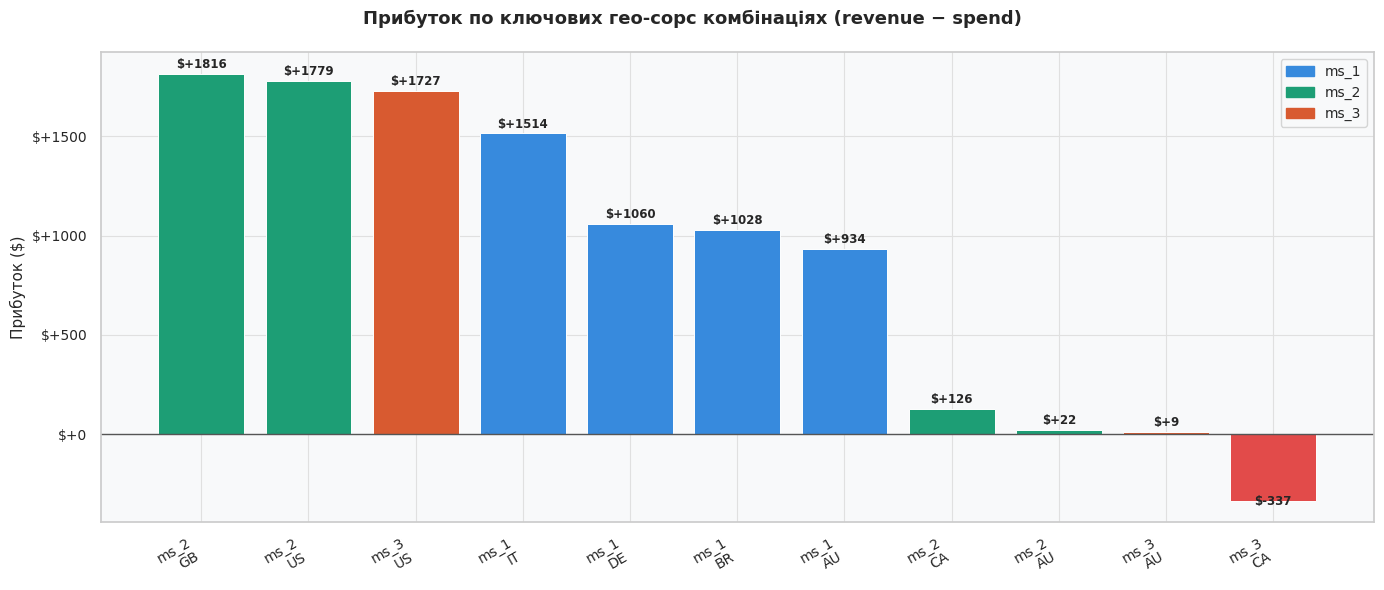

In [42]:
wf_data = []
for ms in ["ms_1", "ms_2", "ms_3"]:
    top = (
        agg[(agg["media_source"] == ms) & (agg["spend"] > 100)]
        .nlargest(4, "profit")[["country_code", "profit"]]
    )
    for _, row in top.iterrows():
        wf_data.append({"label": f"{ms}\n{row['country_code']}", "profit": row["profit"], "ms": ms})

wf_df = pd.DataFrame(wf_data).sort_values("profit", ascending=False)

fig7, ax = plt.subplots(figsize=(14, 6))
fig7.suptitle("Прибуток по ключових гео-сорс комбінаціях (revenue − spend)", fontsize=13, fontweight="bold")

bar_cols = [COLORS[r["ms"]] if r["profit"] >= 0 else "#E24B4A" for _, r in wf_df.iterrows()]
bars = ax.bar(wf_df["label"], wf_df["profit"], color=bar_cols, edgecolor="white", linewidth=0.7)
ax.axhline(0, color="#555", lw=1.0)
ax.set_ylabel("Прибуток ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:+.0f}"))

for bar, val in zip(bars, wf_df["profit"]):
    offset = 15 if val >= 0 else -35
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset,
            f"${val:+.0f}", ha="center", va="bottom", fontsize=8.5, fontweight="bold")

legend_handles = [mpatches.Patch(color=COLORS[ms], label=ms) for ms in ["ms_1","ms_2","ms_3"]]
ax.legend(handles=legend_handles, fontsize=10)
plt.xticks(rotation=30, ha="right")
plt.tight_layout();

ms_2 GB (1816) та ms_2 US (1779) — два найприбутковіші гео-сорс поєднання в абсолютних значеннях. ms_3 US (1727) — третій за прибутком при найнижчих витратах серед трійки (1631 проти 1945 у ms_2 GB).

ms_1 попри значний бюджет представлений у топі лише середніми ринками: IT (1514), DE (1060), BR (1028), AU (934). Жоден із цих результатів не перевищує ефективність ms_2 та ms_3 у US та GB.

Єдиний від’ємний сегмент — ms_3 CA (−337): він фактично зменшує загальний прибуток ms_3, знижуючи його з 1737 до 1428.

## Загальний висновок

### Ефективність медіа-сорсів

Аналіз тижневої когорти (28 грудня 2020 — 3 січня 2021) по трьох медіа-сорсах показує суттєву різницю в ефективності при кардинально різному масштабі закупівлі.

**ms_2 — найефективніший сорс.** При витратах 5860 (9% бюджету) генерує 4409 чистого прибутку, ROAS 1.75× та найнижчий CPS серед платних сорсів — 6.09. Протягом періоду не має збиткових днів. Єдина слабка зона — FR та PR із сукупним мінімальним збитком 176, який можна усунути через відключення цих гео.

**ms_3 — перспективний, але недозавантажений.** При найменшому бюджеті 2177 (3% витрат) показує ROAS 1.66× та найнижчу вартість підписника — 5.11. Водночас платна активність тривала лише 3 дні, географія обмежена 4 країнами, а CA з ROI −83% зменшує потенційний результат. Загалом сорс має високий недореалізований потенціал.

**ms_1 — масштабний, але неефективний.** Поглинає 57078 (88% бюджету), але дає лише 259 прибутку, фактично ROAS ≈ 1.00×. Основна проблема — географічна структура: US (20224 витрат, ROAS 0.77×) та CA (2418, ROAS 0.72×) формують сукупний збиток близько 6300, повністю нівелюючи результати інших гео. При цьому ті ж ринки в ms_2 (US 1.64×, CA 1.65×) є прибутковими, що вказує на проблему не ринку, а підходу до закупівлі.

---

### Ключові структурні проблеми

Розподіл бюджету суттєво не відповідає ефективності. ms_1 отримує у рази більше ресурсів, але має гірші метрики: ROAS у 1.75 раза нижчий, CPS у 2.7 раза вищий, а прибуток у десятки разів менший, ніж у ms_2.

Збиткові гео ms_1 (FI, TR, LU, SA, RO, HK, VN, SE, IN, RU) сумарно спалюють близько 5400 без значного доходу. Перерозподіл цих коштів у прибуткові ринки (IT, BR, UA) або в ms_2/ms_3 міг би суттєво підвищити загальну ефективність без збільшення бюджету.

FR демонструє системну неефективність у різних сорсах (0.48× у ms_1 та 0.60× у ms_2), що свідчить про проблему монетизації або невідповідність продукту ринку, яку не вирішити лише зміною сорсу.

---

### Пріоритети оптимізації

Найбільший миттєвий ефект дасть скорочення або відключення US та CA в ms_1, що вивільнить близько 22700 і усуне основне джерело збитків. Далі — масштабування ms_2 (особливо GB, US, AE з ROAS 4.22×) та ms_3 (US як ключовий драйвер зупинкою CA). Додатково варто протестувати ms_2/ms_3 у гео з високим ROAS ms_1 (IT, BR, UA) для перевірки, чи ефект зумовлений сорсом чи ринком.

За умови оптимального перерозподілу бюджету потенційний тижневий прибуток може зрости з приблизно 6100 до 15000–20000 без зміни загальних витрат — виключно за рахунок структури алокації.
